# Sold Weeks 2-3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sold = pd.read_csv("../../IDX_Data/sold_combined_residential.csv")
print("Shape:", sold.shape)
sold.head()

/var/folders/hx/s9px6scd2pl5dqfp0pldbdgc0000gn/T/ipykernel_71770/316641047.py:5: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("../../IDX_Data/sold_combined_residential.csv")


Shape: (542075, 84)


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [2]:
sold.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [3]:
sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 542075 entries, 0 to 542074
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             541305 non-null  float64
 1   ListingKey                    542075 non-null  int64  
 2   ListAgentEmail                493182 non-null  str    
 3   CloseDate                     161516 non-null  str    
 4   ClosePrice                    140928 non-null  float64
 5   ListAgentFirstName            537816 non-null  str    
 6   ListAgentLastName             542035 non-null  str    
 7   Latitude                      461900 non-null  float64
 8   Longitude                     461900 non-null  float64
 9   UnparsedAddress               541374 non-null  str    
 10  PropertyType                  542075 non-null  str    
 11  LivingArea                    541519 non-null  float64
 12  ListPrice                     542075 non-null  float64


In [4]:
missing = sold.isnull().sum()
missing_pct = (missing / len(sold)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)

missing_df.head(20)

,missing_count,missing_pct
TaxAnnualAmount,542075,100.000000
FireplacesTotal,542075,100.000000
ElementarySchoolDistrict,542075,100.000000
TaxYear,542075,100.000000
BusinessType,542075,100.000000
MiddleOrJuniorSchoolDistrict,542075,100.000000
CoveredSpaces,542075,100.000000
AboveGradeFinishedArea,542075,100.000000
BelowGradeFinishedArea,539039,99.439930
CoBuyerAgentFirstName,528109,97.423604


In [5]:
high_missing = missing_df[missing_df['missing_pct'] > 90]
print("Columns with >90% missing:")
high_missing

Columns with >90% missing:


,missing_count,missing_pct
TaxAnnualAmount,542075,100.000000
FireplacesTotal,542075,100.000000
ElementarySchoolDistrict,542075,100.000000
TaxYear,542075,100.000000
BusinessType,542075,100.000000
MiddleOrJuniorSchoolDistrict,542075,100.000000
CoveredSpaces,542075,100.000000
AboveGradeFinishedArea,542075,100.000000
BelowGradeFinishedArea,539039,99.439930
CoBuyerAgentFirstName,528109,97.423604


In [6]:
cols_to_drop = missing_df[missing_df['missing_pct'] > 90].index.tolist()
print("Columns to drop later:")
cols_to_drop

Columns to drop later:


['TaxAnnualAmount',
 'FireplacesTotal',
 'ElementarySchoolDistrict',
 'TaxYear',
 'BusinessType',
 'MiddleOrJuniorSchoolDistrict',
 'CoveredSpaces',
 'AboveGradeFinishedArea',
 'BelowGradeFinishedArea',
 'CoBuyerAgentFirstName',
 'BuilderName',
 'LotSizeDimensions',
 'BuildingAreaTotal']

In [7]:
numeric_cols = [
    'ClosePrice',
    'ListPrice',
    'OriginalListPrice',
    'LivingArea',
    'LotSizeAcres',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'DaysOnMarket',
    'YearBuilt'
]
sold[numeric_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,1.409280e+05,5.420750e+05,5.413050e+05,5.415190e+05,4.973610e+05,541925.000000,542019.000000,542075.000000,541141.000000
mean,1.201749e+06,1.314032e+06,1.398507e+06,1.979827e+03,6.521435e+01,3.223031,2.626183,19.083180,1979.603771
std,4.358087e+06,2.346976e+06,7.372366e+06,2.334190e+04,1.211659e+04,1.186789,3.253003,26.660849,26.997909
min,5.250000e+02,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-58.000000,1776.000000
1%,2.150000e+05,2.100000e+05,2.000000e+05,5.880000e+02,0.000000e+00,1.000000,1.000000,0.000000,1911.000000
25%,6.000000e+05,5.800000e+05,5.850000e+05,1.247000e+03,1.200000e-01,2.000000,2.000000,5.000000,1961.000000
50%,8.500000e+05,8.450000e+05,8.490000e+05,1.669000e+03,1.700000e-01,3.000000,2.000000,11.000000,1980.000000
75%,1.350000e+06,1.375000e+06,1.389900e+06,2.300000e+03,3.140000e-01,4.000000,3.000000,22.000000,2001.000000
99%,5.500000e+06,8.200000e+06,8.500000e+06,6.300000e+03,1.352010e+01,6.000000,7.000000,139.000000,2025.000000
max,8.200000e+08,1.950000e+08,1.390000e+09,1.702132e+07,4.187292e+06,94.000000,2208.000000,731.000000,2028.000000


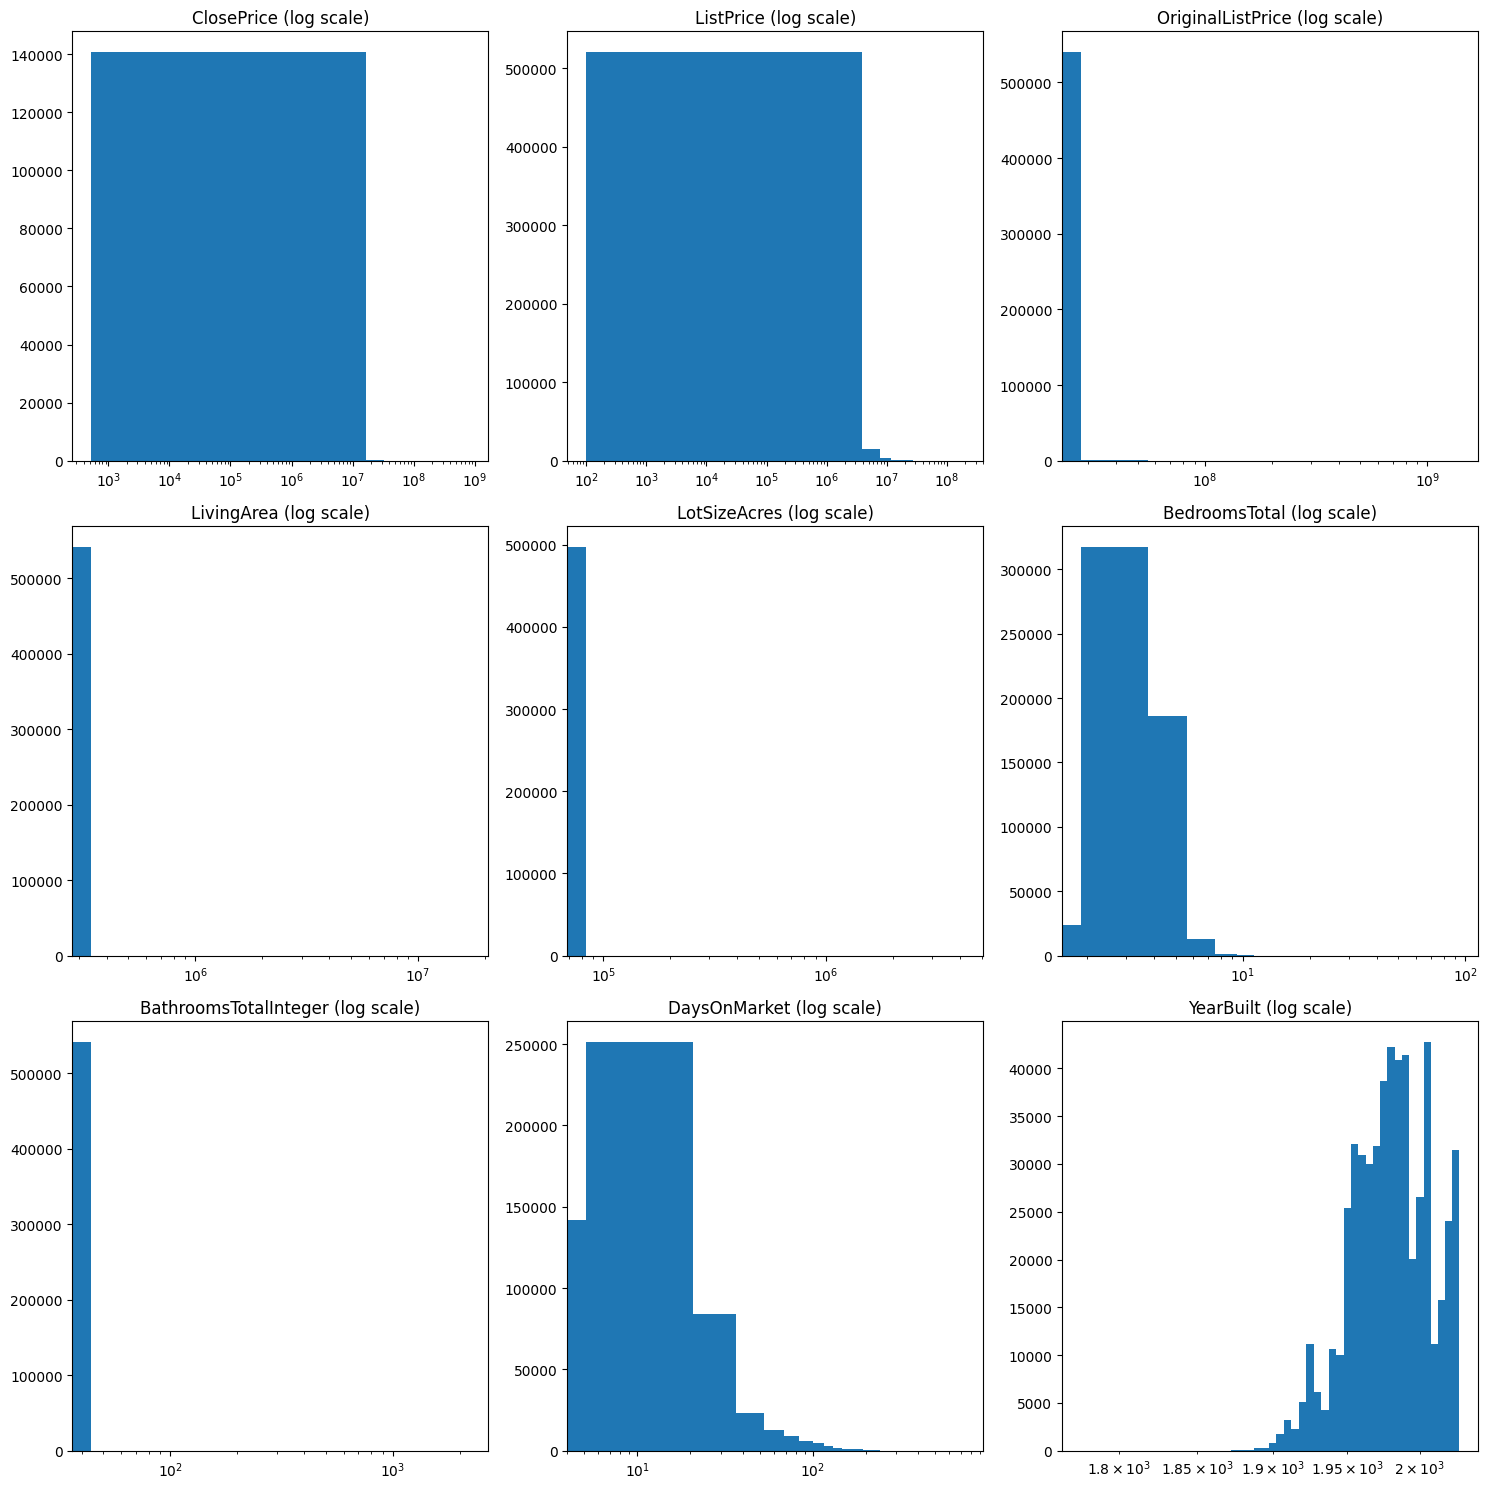

In [8]:
import math
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data = sold[col].dropna()
    
    axes[i].hist(data, bins=50)
    axes[i].set_title(f"{col} (log scale)")
    axes[i].set_xscale('log')

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

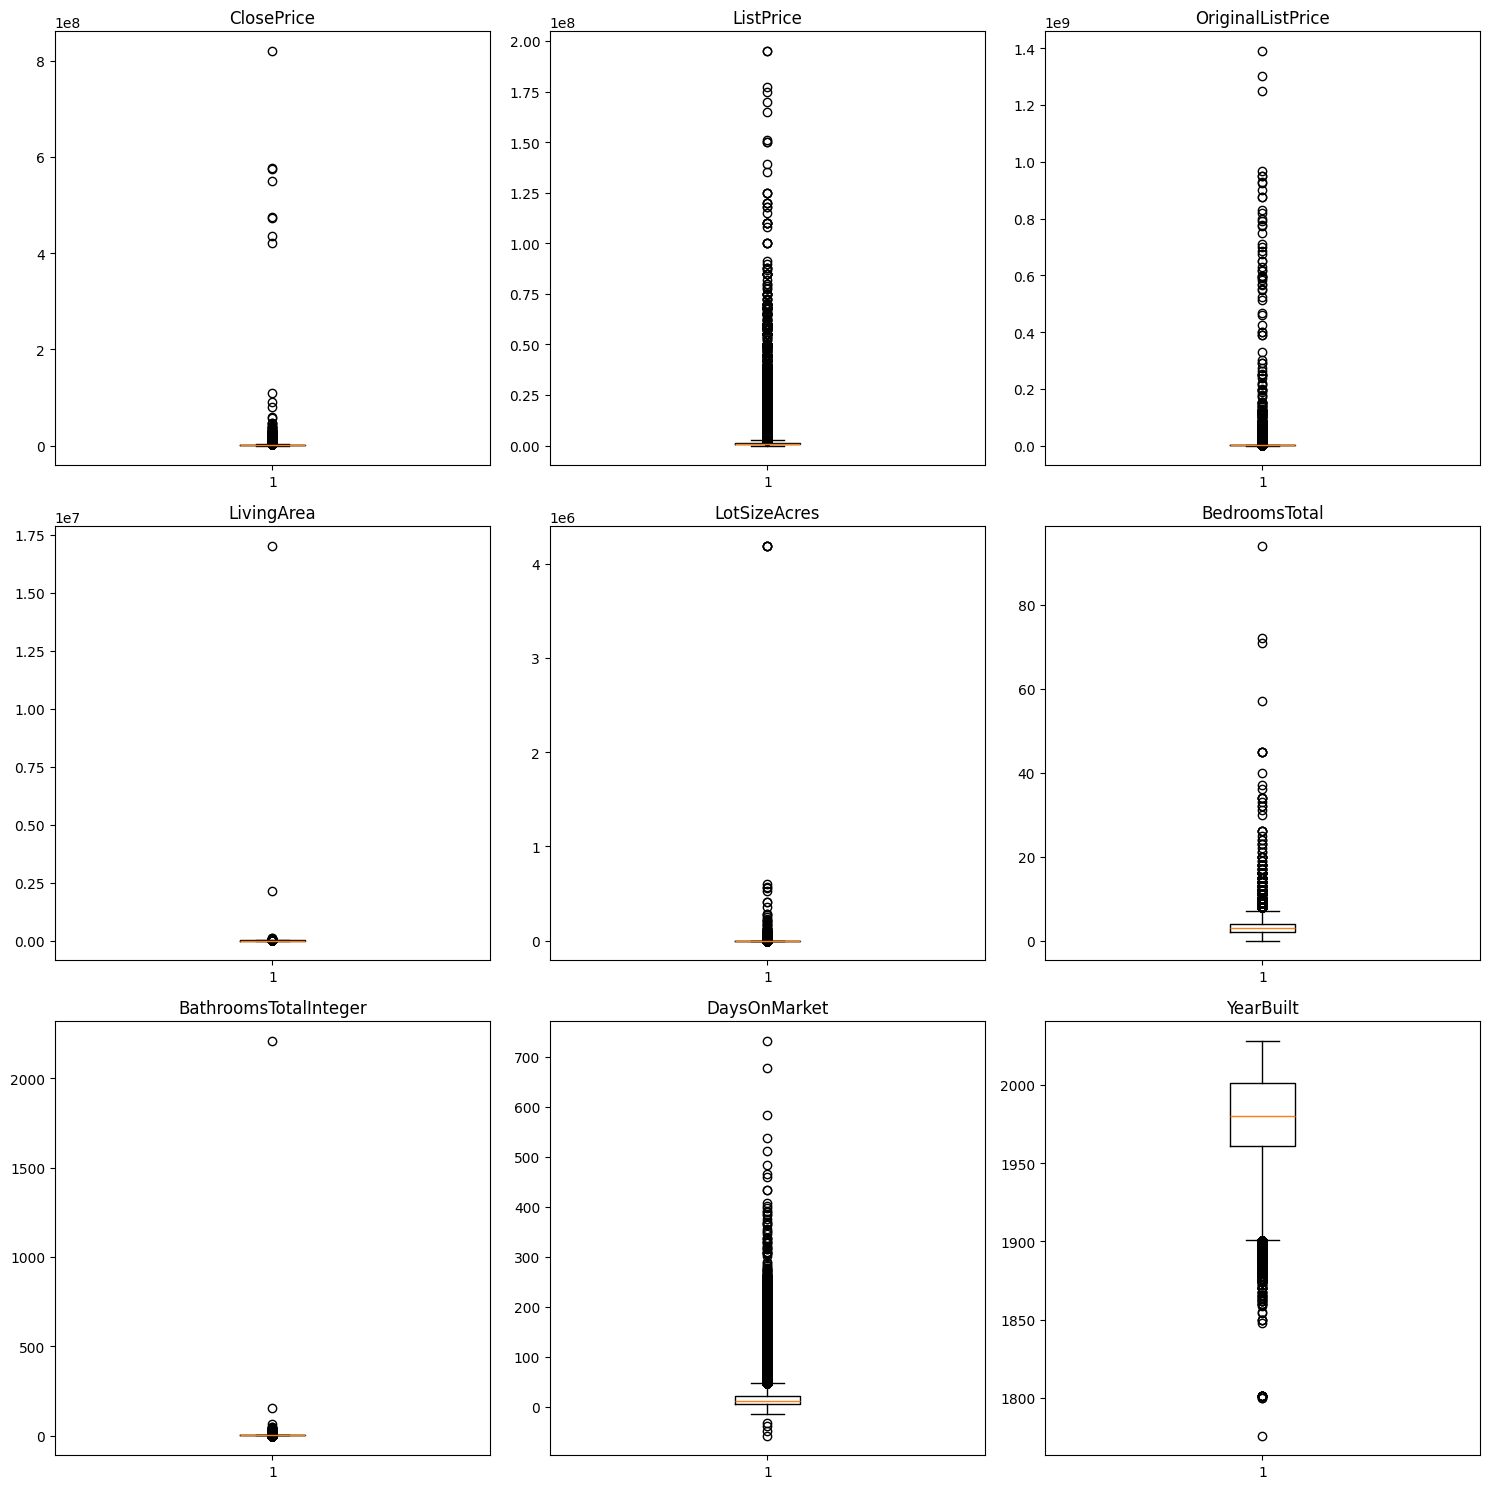

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(sold[col].dropna())
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
median_price = sold['ClosePrice'].median()
mean_price = sold['ClosePrice'].mean()

print("Median:", median_price)
print("Mean:", mean_price)

Median: 850000.0
Mean: 1201749.4200387434


In [11]:
above = (sold['ClosePrice'] > sold['ListPrice']).mean() * 100
below = (sold['ClosePrice'] < sold['ListPrice']).mean() * 100

print("Above list %:", above)
print("Below list %:", below)

Above list %: 11.355070792786975
Below list %: 9.797168288520961


In [12]:
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'], errors='coerce')
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'], errors='coerce')

invalid_dates = (sold['CloseDate'] < sold['ListingContractDate']).sum()

print("Invalid date cases:", invalid_dates)

Invalid date cases: 72


In [13]:
county_prices = (
    sold.groupby('CountyOrParish')['ClosePrice']
    .median()
    .sort_values(ascending=False)
)
county_prices.head(10)

CountyOrParish
San Mateo        1750000.0
Santa Clara      1640000.0
Marin            1345000.0
San Francisco    1244444.0
Santa Cruz       1215000.0
Alameda          1180000.0
Orange           1170000.0
Monterey          915000.0
Los Angeles       915000.0
San Diego         899500.0
Name: ClosePrice, dtype: float64

# Deliverables 

In [14]:
sold['PropertyType'].unique()

<StringArray>
['Residential']
Length: 1, dtype: str

In [15]:
sold = sold[sold['PropertyType'] == 'Residential']
print("Shape after Residential filter:", sold.shape)

Shape after Residential filter: (542075, 84)


In [16]:
null_counts = sold.isnull().sum()
null_counts.sort_values(ascending=False).head(20)

TaxAnnualAmount                 542075
FireplacesTotal                 542075
ElementarySchoolDistrict        542075
TaxYear                         542075
BusinessType                    542075
MiddleOrJuniorSchoolDistrict    542075
CoveredSpaces                   542075
AboveGradeFinishedArea          542075
BelowGradeFinishedArea          539039
CoBuyerAgentFirstName           528109
BuilderName                     516793
LotSizeDimensions               513788
BuildingAreaTotal               493910
ElementarySchool                477495
MiddleOrJuniorSchool            477369
BuyerAgencyCompensation         463082
BuyerAgencyCompensationType     463062
HighSchool                      457327
CoListAgentFirstName            421199
CoListAgentLastName             420799
dtype: int64

In [17]:
print("Columns with >90% missing:")
high_missing

Columns with >90% missing:


,missing_count,missing_pct
TaxAnnualAmount,542075,100.000000
FireplacesTotal,542075,100.000000
ElementarySchoolDistrict,542075,100.000000
TaxYear,542075,100.000000
BusinessType,542075,100.000000
MiddleOrJuniorSchoolDistrict,542075,100.000000
CoveredSpaces,542075,100.000000
AboveGradeFinishedArea,542075,100.000000
BelowGradeFinishedArea,539039,99.439930
CoBuyerAgentFirstName,528109,97.423604


In [18]:
sold[['ClosePrice', 'LivingArea', 'DaysOnMarket']].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
)

,ClosePrice,LivingArea,DaysOnMarket
count,1.409280e+05,5.415190e+05,542075.000000
mean,1.201749e+06,1.979827e+03,19.083180
std,4.358087e+06,2.334190e+04,26.660849
min,5.250000e+02,0.000000e+00,-58.000000
1%,2.150000e+05,5.880000e+02,0.000000
5%,3.530000e+05,8.160000e+02,0.000000
50%,8.500000e+05,1.669000e+03,11.000000
95%,2.900000e+06,3.867000e+03,71.000000
99%,5.500000e+06,6.300000e+03,139.000000
max,8.200000e+08,1.702132e+07,731.000000


In [19]:
sold.to_csv("sold_filtered_week2_3.csv", index=False)
print("Saved filtered dataset.")

Saved filtered dataset.
